In [1]:
import json
from datetime import datetime
from pathlib import Path
from typing import Optional, Tuple, Dict

#from data.minbpe import BasicTokenizer as Tokenizer
from src.minbpe import RegexTokenizer as Tokenizer
from src.gpt import GPTLanguageModel

import matplotlib.pyplot as plt
import torch
torch.manual_seed(3647)
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

def print_model_structure(model: nn.Module, indent: str = '') -> None:
    """
    Custom function to print model structure in a hierarchical format
    """
    for name, child in model.named_children():
        params = sum(p.numel() for p in child.parameters())
        print(f"{indent}├─ {name}: {child.__class__.__name__} ({params:,} parameters)")
        print_model_structure(child, indent + '│  ')

class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index:index + self.block_size]
        y = self.data[index + 1:index + self.block_size + 1]
        return x, y

def get_dataloaders(
        train_data: torch.Tensor,
        val_data: torch.Tensor,
        block_size: int,
        batch_size: int,
        device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [3]:
tokenizer_dir = Path("data") / "tokenizer"

tokenizer = Tokenizer()
tokenizer.load(model_file=str(tokenizer_dir / "tokenizer.model"))

train_data = torch.load(tokenizer_dir / 'train.tokens.pt')
val_data = torch.load(tokenizer_dir / 'validation.tokens.pt')

print(f"--> train_data: {train_data.size()[0]:_}, val_data: {val_data.size()[0]:_}")

--> train_data: 12_092_088, val_data: 616_680


In [4]:
#### model parameters
parameters = {
  'vocab_size': len(tokenizer.vocab),
  'n_embd': 512,
  'block_size': 256,
  'n_head': 8,
  'n_layer': 4,
  'dropout': 0.2,
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#### training parameters
iter_start, max_iters = 1, 1
 batch_start = 0
learning_rate = 3e-4
batch_size = 32 # 64
eval_interval = 1000
eval_iters = 1000

model = GPTLanguageModel(
    vocab_size=parameters['vocab_size'],
    n_embd=parameters['n_embd'],
    block_size=parameters['block_size'],
    n_head=parameters['n_head'],
    n_layer=parameters['n_layer'],
    dropout=parameters['dropout'],
    device=device,
).to(device)

model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
# optimizer.param_groups[0]['lr']

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')
#print_model_structure(model)

--> 13.8M parameters


In [5]:
checkpoint_dir = Path("data") / "ch02_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoints = sorted(
    checkpoint_dir.glob("checkpoint_*.pt"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=True,
)

if len(checkpoints) > 0:
    last_ckpt = torch.load(checkpoints[0], map_location=device)
    nums = checkpoints[0].name.replace("checkpoint_", "").replace(".pt", "").split("-", 1)
    iter_start = int(nums[0])
    batch_start = int(nums[1]) + 1
    meta = last_ckpt['meta']
    print(f"--> resume_from_checkpoint: path={checkpoints[0]}, created_at={meta['created_at']}, iter_start={iter_start}, batch_start={batch_start}")

    model.load_state_dict(last_ckpt['model_state_dict'])
    optimizer.load_state_dict(last_ckpt['optimizer_state_dict'])
else:
    print("No last checkpoints found")

--> resume_from_checkpoint: path=data/ch02_checkpoints/checkpoint_001-061000.pt, created_at=2025-09-01T15:04:33+08:00, iter_start=1, batch_start=61001


In [6]:
@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int,
) -> Dict[str, float]:
    output = {}
    model.eval() # 评估模式

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = torch.zeros(eval_iters)
        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break

            with torch.no_grad():
                _, loss = model(x, y) # 前向传播（Forward Pass）
            losses[i] = loss.item()
        output[split] = losses.mean().item()

    model.train() # 切换到为推理
    return output

def estimate_and_save(iteration, batch_n, loss_val):
    losses = estimate_loss(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        eval_iters=min(eval_iters, len(val_loader)),
    )
    train_losses.append(losses['train'])
    val_losses.append(losses['val'])

    print("{} iteration={:03}, step={:07_}, train_loss={:.3f}, val_loss={:.3f}".format(
        now(), iteration, batch_n, losses['train'], losses['val'],
    ))

    # Save checkpoint
    checkpoint_prefix = str(checkpoint_dir / f"checkpoint_{iteration:03d}-{batch_n:06d}")

    meta = {
        'created_at': now(),
        'parameters': parameters,
        'epoch': iteration,
        'batch_n': batch_n,
        'loss': loss_val,
        'train_loss': losses['train'],
        'eval_loss': losses['val'],
    }

    checkpoint = {
        'meta': meta,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    with open(checkpoint_prefix + ".json", 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=4)

    torch.save(checkpoint, checkpoint_prefix+".pt")
    print(f"{now()} saved checkpoint: {checkpoint_prefix}.pt, loss: {loss_val:.3f}")

In [7]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=parameters['block_size'],
    batch_size=batch_size,
    device=device,
)

train_losses, val_losses = [], []

In [ ]:
for iteration in range(iter_start, max_iters+1):
    print(f"{now()} iteration={iteration}, batch_start={batch_start}")
    # train_data.shape[0]/batch_size = 260.36k, 
    # train_loader = data[N, 2, batch_size, block_size]
    loss_val = 0
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader, start=batch_start):
        # Evaluation
        batch_n = batch_idx + 1
        if batch_n % eval_interval == 0 or batch_n == len(train_loader):
            estimate_and_save(iteration, batch_n, loss_val)

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_val = loss.item()

    batch_start = 0 # !!! Caution

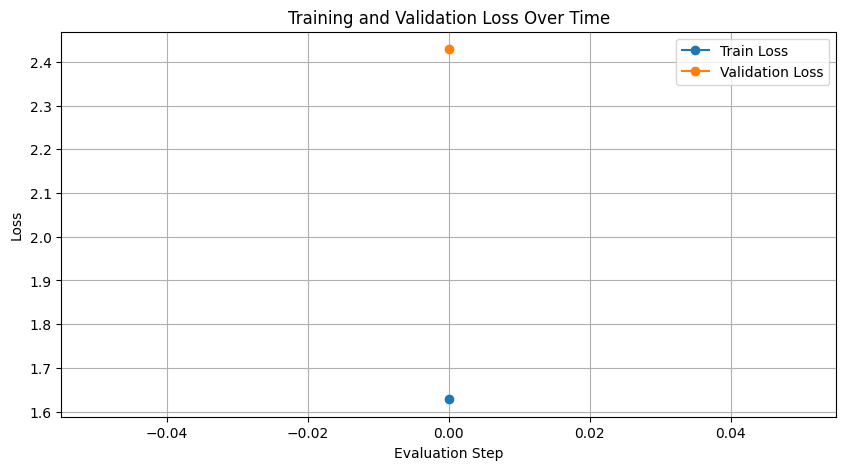

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()
# 2025-08-24T08:37:24+08:00 iteration=001, step=119_800, train_loss=1.606, val_loss=2.304

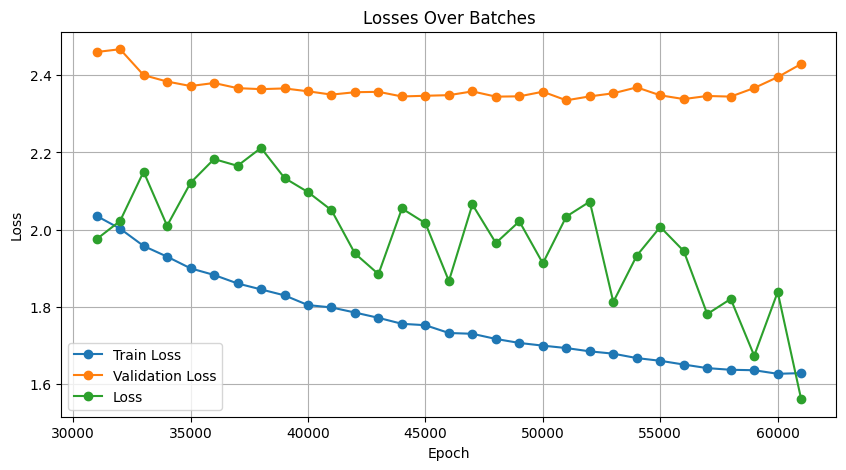

In [8]:
# checkpoint_dir = Path("data") / "ch02_checkpoints"
json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

batches, loss, train_losses, val_losses = [], [], [], []

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    batches.append(data['batch_n'])
    loss.append(data['loss'])
    train_losses.append(data['train_loss'])
    val_losses.append(data['eval_loss'])

plt.figure(figsize=(10, 5))
plt.plot(batches, train_losses, label="Train Loss", marker='o')
plt.plot(batches, val_losses, label="Validation Loss", marker='o')
plt.plot(batches, loss, label="Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Batches")
plt.legend()
plt.grid()
plt.show()